----

# Construccion de modelo epidemiologico a partir de datos

---



### Generar Datos Modelo epidemiológico SIR



 El sistema de ecuaciones diferenciales que describe el sistema es:

<br>
\begin{eqnarray}
 \dfrac{d S}{dt} &=& - \dfrac{\beta S I}{N},\\
 \dfrac{d I}{dt} &=&  \dfrac{\beta S I}{N}- \gamma  I,\\
 \dfrac{d R}{dt} &=&  \gamma I ,
\end{eqnarray}
<br>

Donde $N$ es la población total, es decir $N= S+I+R$.


<br>

Con lo anterior y suponiendo que se tiene una epidemia con condiciones iniciales condiciones iniciales         $S_0 = 9990$, $I_0 =10$ $R_0 = 0$ y parámetros $\beta = 2.7 $, $ \gamma = 0.4$ :


**Nota:** En este modelo no se consideran muertes ni nacimientos, la población es fija.



**Solución (usando el metodo de adams)**

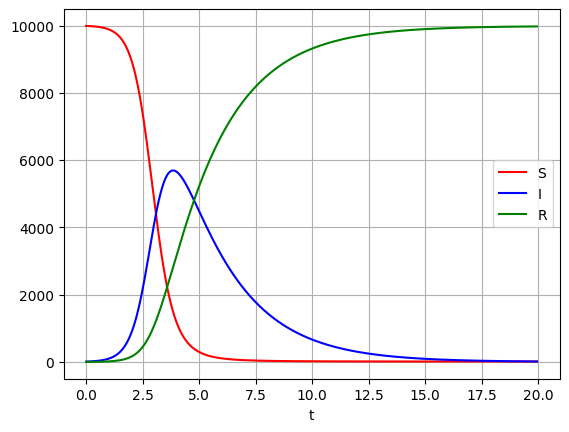

In [1]:
import numpy as np
import matplotlib.pyplot as plt



# Parametros del sistema
beta  = 2.7
gamma = 0.4


#-------Sistema de Ecuaciones diferenciales---------
def FS(S, I, R):
    return -beta * S * I/(R+I+S)

def FI(S, I, R):
    return beta * S * I/(R+I+S) - gamma * I

def FR(S, I, R):
    return gamma * I
#--------------------------------------------------

#numero de pasos
t0 = 0
tf = 20
dt = 1/24
t  = np.arange(t0,tf, dt)


# Condiciones iniciales

#poblacion total
N = 10000

S0 = 9990 # Dsuceptibles iniciales
I0 = 10 # infectados iniciales
R0 = 0 #recuperados iniciales

# Definiendo los vectores nulos para almacenar los datos
S = np.zeros(len(t))
I = np.zeros(len(t))
R = np.zeros(len(t))


#Llenando los primeros datos
S[0] = S0
I[0] = I0
R[0] = R0


#Usando el metodo de Euler
S[1] = S[0] + dt * FS( S[0] , I[0], R[0] )
I[1] = I[0] + dt * FI( S[0] , I[0], R[0] )
R[1] = R[0] + dt * FR( S[0] , I[0], R[0] )


#Usando el metodo de Adams
for i in range(1, len(t)-1  ):
    S[i+1] = S[i] + (dt/2) * ( 3* FS( S[i] , I[i], R[i] ) - FS( S[i-1] , I[i-1], R[i-1] )  )


    I[i+1] = I[i] + (dt/2) * ( 3* FI( S[i] , I[i], R[i] ) - FI( S[i-1] , I[i-1], R[i-1] )  )


    R[i+1] = R[i] + (dt/2) * ( 3* FR( S[i] , I[i], R[i] ) - FR( S[i-1] , I[i-1], R[i-1] )  )



# Graficas
plt.plot(t, S, '-r', label ='S')
plt.plot(t, I, '-b', label ='I')
plt.plot(t, R, '-g', label ='R')
plt.xlabel('t')
plt.grid()
plt.legend()
plt.savefig('ModeloSIRFig1.pdf', format='pdf', bbox_inches='tight')
plt.show()


###Tabla de datos

In [2]:
import numpy as np
import pandas as pd

# hacer dos columnas, crear un arreglo
datos = pd.DataFrame( {'tiempo':t ,'suceptibles': np.round(S,0), 'infectados':np.round(I,0), 'recuperados':np.round(R,0)  }  )

#Guardado de numpy!!!!
datos.to_csv('datos.csv')



----------------------
----------------------
##Construccion de Modelo SIR
---------------------
----------------------

El modelo SIR (*Susceptible-Infectado-Recuperado*) es una herramienta matemática utilizada para describir la propagación de enfermedades infecciosas en una población. Los parámetros clave en este modelo son:

<br>

- $S(t)$: Número de individuos susceptibles en el tiempo $t$.

- $I(t)$: Número de individuos infectados en el tiempo $t$.

- $R(t)$: Número de individuos recuperados en el tiempo $t$.

<br>

Los parámetros adicionales son:
<br>
- $\beta$: Tasa de infección por contacto.
- $\gamma$: Tasa de recuperación.

<br>


 El sistema de ecuaciones diferenciales que describe el sistema es:

<br>
\begin{eqnarray}
 \dfrac{d S}{dt} &=& - \dfrac{\beta S I}{N},\\
 \dfrac{d I}{dt} &=&  \dfrac{\beta S I}{N}- \gamma  I,\\
 \dfrac{d R}{dt} &=&  \gamma I ,
\end{eqnarray}
<br>

Donde $N$ es la población total, es decir $N= S+I+R$.


<br>

Con lo anterior y suponiendo que se tiene una epidemia con condiciones iniciales condiciones iniciales         $S_0 = 9990$, $I_0 =10$ $R_0 = 0$.  

<br>


1. Apartir de la tabla de datos $\texttt{datos.dat}$, estime el valor de los parametros $\beta$ y $\gamma$ usando una regresion lineal.

<br>

2. Resuelva el sistema y grafique las curvas de de evolución de las variables S, I y R.

<br>

3. Segun la curva obtenida, estime cuando sera el "pico" de la epidemia, es decir; estime cuando se dara la mayor cantidad de contagios.

<br>

4. Según las curvas obtenidas, cuando estaría  recuperada mas del el $90 \%$ de la población.

<br>

5. Podría ajustar este modelo para modelar el comportamiento del corona virus?


<br>

**Nota:** En este modelo no se consideran muertes ni nacimientos, la población es fija.




<br>

**Solucion:**

 <br>

## 1. Estimar el valor de los parametros del sistema

Cargamos los datos

In [27]:
datosRecuperados = pd.read_csv('datos.csv')

# obtener los datos por separado (Note automaticamente descarta los headers!!!)
t = datosRecuperados['tiempo'].to_numpy() # toda la primera columna
S = datosRecuperados['suceptibles'].to_numpy() # toda la segunda columna
I = datosRecuperados['infectados'].to_numpy() # toda la primera columna
R = datosRecuperados['recuperados'].to_numpy() # toda la segunda columna


Considere la ecuacion (1).

 $$\dfrac{d S}{dt} = - \dfrac{\beta S I}{N}$$


Esta ecuacion puede definir la ecuacion en diferencias

 $$\dfrac{ \Delta S}{ \Delta t} ≈  \beta  \left(  \dfrac{ - S I}{N} \right)$$


Por lo tanto, si graficamos $\dfrac{ \Delta S}{ \Delta t} $ contra $\dfrac{- S I}{N}$, debemos tener un grafico de una recta con pendiente $\beta$. Por tanto

In [29]:
#Considero los arreglos de los cambios!
Dt  = t[1:] - t[0:-1]
DS  = S[1:] - S[0:-1]
DI  = I[1:] - I[0:-1]
DR  = R[1:] - R[0:-1]



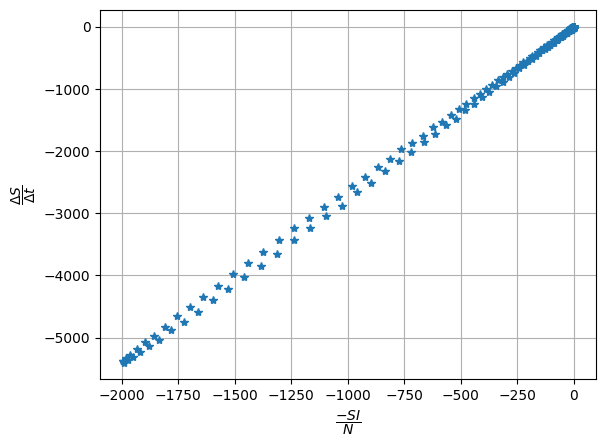

In [30]:
 #Grafico de sucesion 1
import numpy as np
import matplotlib.pyplot as plt


plt.plot( -I[0:-1] * S[0:-1] / 10000 , DS/Dt ,  '*'  )
plt.ylabel(r'$\dfrac{ \Delta S}{ \Delta t} $')
plt.xlabel(r'$\dfrac{- S I}{N}$')
plt.grid()

Estimamos el valor de $\beta$ haciendo uan regresion lineal

In [32]:
#Estimar el valor de beta

from scipy import stats   # Carga el módulo de herramientas estadísticas


#Haciendo la regresion lineal con scipy
regresion_lineal = stats.linregress( -I[0:-1] * S[0:-1] / 10000 , DS/Dt )

# Resultados del análisis
beta         = regresion_lineal.slope       # Pendiente

print("el valor de BETA es = ", beta  )


el valor de BETA es =  2.7013141275884456


De forma analoga, considere la ecuacion (3).

 $$\dfrac{d R}{dt} = \gamma  I$$


Esta ecuacion puede definir la ecuacion en diferencias

 $$\dfrac{ \Delta R}{ \Delta t} ≈ \gamma  I$$


Por lo tanto, si graficamos $\dfrac{ \Delta R}{ \Delta t} $ contra $I$, debemos tener un grafico de una recta con pendiente $\gamma$. Por tanto

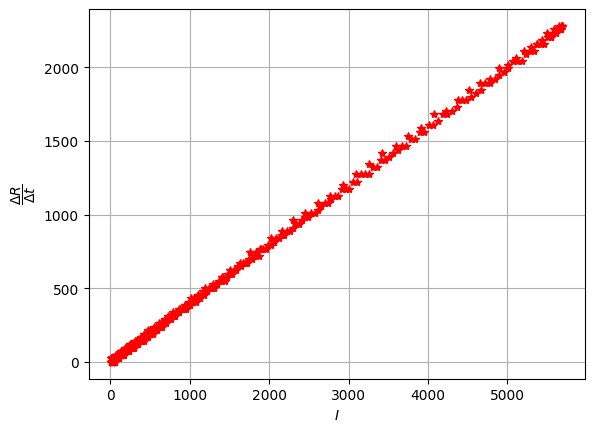

In [33]:
#Grafico de sucesion 3
plt.plot( I[0:-1]  , DR/Dt  , 'r*' )
plt.ylabel(r'$\dfrac{ \Delta R}{ \Delta t}$')
plt.xlabel(r'$I$')
plt.grid()

Estimamos el valor de $\gamma$ haciendo uan regresion lineal

In [34]:
#Estimar el valor de gamma

from scipy import stats   # Carga el módulo de herramientas estadísticas


#Haciendo la regresion lineal con scipy
regresion_lineal = stats.linregress( I[0:-1]  , DR/Dt  )

# Resultados del análisis
gamma         = regresion_lineal.slope       # Pendiente

print("el valor de gamma es = ", gamma  )


el valor de gamma es =  0.40006878019134945


## 2. Resolver numericamente el modelo SIR

**Solución (usando el metodo de adams)**

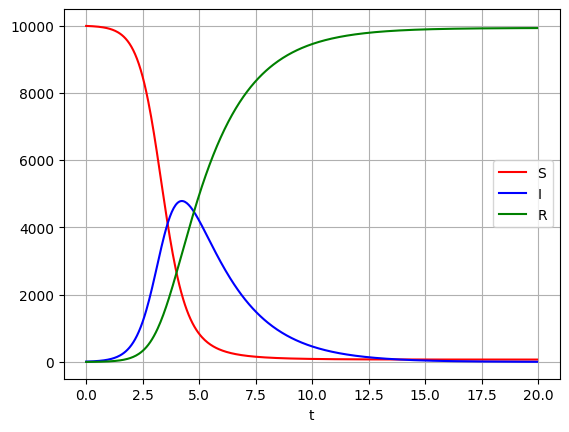

In [35]:
import numpy as np
import matplotlib.pyplot as plt



# Parametros del sistema APROXIMADOS!!!!
beta  = 2.5
gamma = 0.5


#-------Sistema de Ecuaciones diferenciales---------
def FS(S, I, R):
    return -beta * S * I/(R+I+S)

def FI(S, I, R):
    return beta * S * I/(R+I+S) - gamma * I

def FR(S, I, R):
    return gamma * I
#--------------------------------------------------

#numero de pasos
t0 = 0
tf = 20
dt = 1/24
t  = np.arange(t0,tf, dt)


# Condiciones iniciales

#poblacion total
N = 10000

S0 = 9990 # Dsuceptibles iniciales
I0 = 10 # infectados iniciales
R0 = 0 #recuperados iniciales

# Definiendo los vectores nulos para almacenar los datos
S = np.zeros(len(t))
I = np.zeros(len(t))
R = np.zeros(len(t))


#Llenando los primeros datos
S[0] = S0
I[0] = I0
R[0] = R0


#Usando el metodo de Euler
S[1] = S[0] + dt * FS( S[0] , I[0], R[0] )
I[1] = I[0] + dt * FI( S[0] , I[0], R[0] )
R[1] = R[0] + dt * FR( S[0] , I[0], R[0] )


#Usando el metodo de Adams
for i in range(1, len(t)-1  ):
    S[i+1] = S[i] + (dt/2) * ( 3* FS( S[i] , I[i], R[i] ) - FS( S[i-1] , I[i-1], R[i-1] )  )


    I[i+1] = I[i] + (dt/2) * ( 3* FI( S[i] , I[i], R[i] ) - FI( S[i-1] , I[i-1], R[i-1] )  )


    R[i+1] = R[i] + (dt/2) * ( 3* FR( S[i] , I[i], R[i] ) - FR( S[i-1] , I[i-1], R[i-1] )  )



# Graficas
plt.plot(t, S, '-r', label ='S')
plt.plot(t, I, '-b', label ='I')
plt.plot(t, R, '-g', label ='R')
plt.xlabel('t')
plt.grid()
plt.legend()
plt.savefig('ModeloSIRFig1.pdf', format='pdf', bbox_inches='tight')
plt.show()


## 3. Inferir respuesta de pregunta del grafico

**Respuesta:** Claramente de la grafica de los infectados se observa que la mayor cantidad de contagios se dara alrededor de los 4 dias.

##4. Calcular cuando se alcanzara el 90% de recuperados

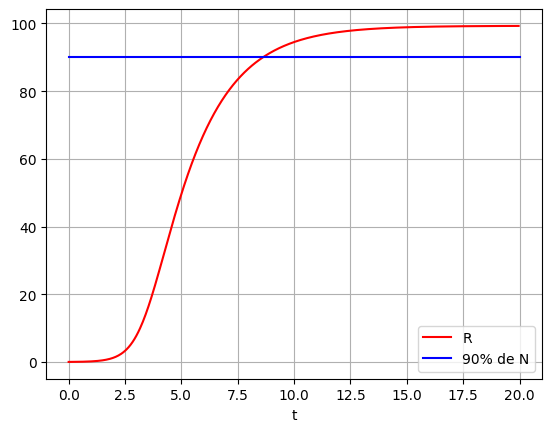

In [36]:
# El porcentaje de individuos recuperados

Rporcentaje = R / N *100

#graficando el porcentaje e dias
plt.plot(t, Rporcentaje, '-r', label ='R')

#graficando la lineal que delimita el 90 porciento
plt.plot( [0,20], [ 90 , 90], '-b', label ='90% de N')

plt.xlabel('t')


plt.grid()
plt.legend()
plt.savefig('ModeloSIRFig2.pdf', format='pdf', bbox_inches='tight')
plt.show()


- De la gráfica se puede inferir que despues de 8 dias aproximadamente se recuperaran mas del 90% de la población.

##5. Puede el modelo describir el comportamiento del corona virus

**Respuesta:**  No, este modelo NO puede ajustarse al corona virus porque NO se consideran muertes ni individuos inmunes.